# 02 — Profitability Analysis
## Nassau Candy Distributor — Product Line Profitability & Margin Performance Analysis

Builds product-level profitability metrics (margin, profit per unit, revenue/profit contribution) from the
cleaned transaction data and ranks products using clearly documented thresholds.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/cleaned_transactions.csv', parse_dates=['Order Date'])
print(f"Loaded {df.shape[0]:,} cleaned transaction rows")

Loaded 9,881 cleaned transaction rows


## 1. Core Metric Definitions

- **Gross Profit** = Sales − Cost *(already present and validated in Notebook 1; not recreated)*
- **Gross Margin (%)** = Gross Profit / Sales × 100
- **Profit Per Unit** = Gross Profit / Units
- **Revenue Contribution (%)** = Product Sales / Total Sales × 100
- **Profit Contribution (%)** = Product Gross Profit / Total Gross Profit × 100

Since Sales, Units, and Gross Profit are strictly positive for every row (verified in Notebook 1), there is
no division-by-zero risk in any of these ratios at the transaction level. The same is true after aggregating
to product level, since every product has at least one transaction with positive Sales/Units by construction.
A defensive `replace(0, np.nan)` is still used before dividing, purely as a safeguard.

## 2. Aggregate to Product Level

In [2]:
product = df.groupby(['Product ID', 'Product Name', 'Division']).agg(
    Sales=('Sales', 'sum'),
    Units=('Units', 'sum'),
    Cost=('Cost', 'sum'),
    Gross_Profit=('Gross Profit', 'sum'),
    Transactions=('Row ID', 'count'),
).reset_index()

total_sales = product['Sales'].sum()
total_profit = product['Gross_Profit'].sum()

product['Gross_Margin_Pct'] = product['Gross_Profit'] / product['Sales'].replace(0, np.nan) * 100
product['Profit_Per_Unit'] = product['Gross_Profit'] / product['Units'].replace(0, np.nan)
product['Revenue_Contribution_Pct'] = product['Sales'] / total_sales * 100
product['Profit_Contribution_Pct'] = product['Gross_Profit'] / total_profit * 100

product = product.sort_values('Sales', ascending=False).reset_index(drop=True)
product.round(2)

,Product ID,Product Name,Division,Sales,Units,Cost,Gross_Profit,Transactions,Gross_Margin_Pct,Profit_Per_Unit,Revenue_Contribution_Pct,Profit_Contribution_Pct
0,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,27648.75,7373,9584.90,18063.85,1944,65.33,2.45,19.99,19.83
1,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27028.80,7508,8258.80,18770.00,1994,69.44,2.50,19.55,20.61
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26256.75,8079,9210.06,17046.69,2074,64.92,2.11,18.99,18.72
3,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24361.20,6767,8120.40,16240.80,1771,66.67,2.40,17.62,17.83
4,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,22897.89,6561,6561.00,16336.89,1748,71.35,2.49,16.56,17.94
5,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,94,50.00,10.00,5.68,4.32
6,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.00,92.75,96,7.69,0.25,0.87,0.10
7,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.80,310.70,120,52.00,0.65,0.43,0.34
8,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,3,80.00,8.00,0.09,0.11
9,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,21,31.50,47.25,6,60.00,2.25,0.06,0.05


## 3. Margin Volatility Over Time

In [3]:
# For each product, compute month-level gross margin, then take the standard deviation across months
# as a measure of how stable/volatile the product's margin is over the 2-year window.
df['Order Year-Month'] = df['Order Date'].dt.to_period('M').astype(str)
monthly_prod = df.groupby(['Product ID', 'Order Year-Month']).agg(
    Sales=('Sales', 'sum'), Gross_Profit=('Gross Profit', 'sum')
).reset_index()
monthly_prod['Margin'] = monthly_prod['Gross_Profit'] / monthly_prod['Sales'].replace(0, np.nan) * 100

vol = monthly_prod.groupby('Product ID')['Margin'].agg(
    Margin_Volatility_StdDev='std', Months_Active='count'
).reset_index()

product = product.merge(vol, on='Product ID', how='left')
product[['Product Name', 'Gross_Margin_Pct', 'Margin_Volatility_StdDev', 'Months_Active']].round(2)

,Product Name,Gross_Margin_Pct,Margin_Volatility_StdDev,Months_Active
0,Wonka Bar - Triple Dazzle Caramel,65.33,0.0,24
1,Wonka Bar -Scrumdiddlyumptious,69.44,0.0,24
2,Wonka Bar - Milk Chocolate,64.92,0.0,24
3,Wonka Bar - Fudge Mallows,66.67,0.0,24
4,Wonka Bar - Nutty Crunch Surprise,71.35,0.0,24
5,Lickable Wallpaper,50.00,0.0,21
6,Kazookles,7.69,0.0,24
7,Wonka Gum,52.00,0.0,24
8,Everlasting Gobstopper,80.00,0.0,3
9,Fizzy Lifting Drinks,60.00,0.0,5


**Interpretation:** `Margin_Volatility_StdDev` is the month-to-month standard deviation of a
product's gross margin. A low value means the product's margin is consistently stable across the two-year
window; a higher value flags a product whose profitability swings more from month to month.

## 4. Product Profitability Table

In [4]:
product_table = product[[
    'Product ID', 'Product Name', 'Division', 'Sales', 'Units', 'Cost', 'Gross_Profit',
    'Gross_Margin_Pct', 'Profit_Per_Unit', 'Revenue_Contribution_Pct', 'Profit_Contribution_Pct',
    'Margin_Volatility_StdDev', 'Transactions'
]].round(2)

product_table.to_csv('../data/product_profitability.csv', index=False)
product_table

,Product ID,Product Name,Division,Sales,Units,Cost,Gross_Profit,Gross_Margin_Pct,Profit_Per_Unit,Revenue_Contribution_Pct,Profit_Contribution_Pct,Margin_Volatility_StdDev,Transactions
0,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,Chocolate,27648.75,7373,9584.90,18063.85,65.33,2.45,19.99,19.83,0.0,1944
1,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,Chocolate,27028.80,7508,8258.80,18770.00,69.44,2.50,19.55,20.61,0.0,1994
2,CHO-MIL-31000,Wonka Bar - Milk Chocolate,Chocolate,26256.75,8079,9210.06,17046.69,64.92,2.11,18.99,18.72,0.0,2074
3,CHO-FUD-51000,Wonka Bar - Fudge Mallows,Chocolate,24361.20,6767,8120.40,16240.80,66.67,2.40,17.62,17.83,0.0,1771
4,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,Chocolate,22897.89,6561,6561.00,16336.89,71.35,2.49,16.56,17.94,0.0,1748
5,OTH-LIC-15000,Lickable Wallpaper,Other,7860.00,393,3930.00,3930.00,50.00,10.00,5.68,4.32,0.0,94
6,OTH-KAZ-38000,Kazookles,Other,1205.75,371,1113.00,92.75,7.69,0.25,0.87,0.10,0.0,96
7,OTH-GUM-21000,Wonka Gum,Other,597.50,478,286.80,310.70,52.00,0.65,0.43,0.34,0.0,120
8,SUG-EVE-47000,Everlasting Gobstopper,Sugar,130.00,13,26.00,104.00,80.00,8.00,0.09,0.11,0.0,3
9,OTH-FIZ-56000,Fizzy Lifting Drinks,Sugar,78.75,21,31.50,47.25,60.00,2.25,0.06,0.05,0.0,6


## 5. Rankings

In [5]:
print("=== Top 5 Products by Sales ===")
display(product_table.sort_values('Sales', ascending=False).head(5)[['Product Name', 'Sales']])

print("\n=== Top 5 Products by Gross Profit ===")
display(product_table.sort_values('Gross_Profit', ascending=False).head(5)[['Product Name', 'Gross_Profit']])

print("\n=== Top 5 Products by Gross Margin % ===")
display(product_table.sort_values('Gross_Margin_Pct', ascending=False).head(5)[['Product Name', 'Gross_Margin_Pct']])

print("\n=== Top 5 Products by Profit Per Unit ===")
display(product_table.sort_values('Profit_Per_Unit', ascending=False).head(5)[['Product Name', 'Profit_Per_Unit']])

=== Top 5 Products by Sales ===


,Product Name,Sales
0,Wonka Bar - Triple Dazzle Caramel,27648.75
1,Wonka Bar -Scrumdiddlyumptious,27028.80
2,Wonka Bar - Milk Chocolate,26256.75
3,Wonka Bar - Fudge Mallows,24361.20
4,Wonka Bar - Nutty Crunch Surprise,22897.89



=== Top 5 Products by Gross Profit ===


,Product Name,Gross_Profit
1,Wonka Bar -Scrumdiddlyumptious,18770.00
0,Wonka Bar - Triple Dazzle Caramel,18063.85
2,Wonka Bar - Milk Chocolate,17046.69
4,Wonka Bar - Nutty Crunch Surprise,16336.89
3,Wonka Bar - Fudge Mallows,16240.80



=== Top 5 Products by Gross Margin % ===


,Product Name,Gross_Margin_Pct
8,Everlasting Gobstopper,80.00
10,Hair Toffee,77.78
4,Wonka Bar - Nutty Crunch Surprise,71.35
1,Wonka Bar -Scrumdiddlyumptious,69.44
3,Wonka Bar - Fudge Mallows,66.67



=== Top 5 Products by Profit Per Unit ===


,Product Name,Profit_Per_Unit
5,Lickable Wallpaper,10.00
8,Everlasting Gobstopper,8.00
10,Hair Toffee,3.50
1,Wonka Bar -Scrumdiddlyumptious,2.50
4,Wonka Bar - Nutty Crunch Surprise,2.49


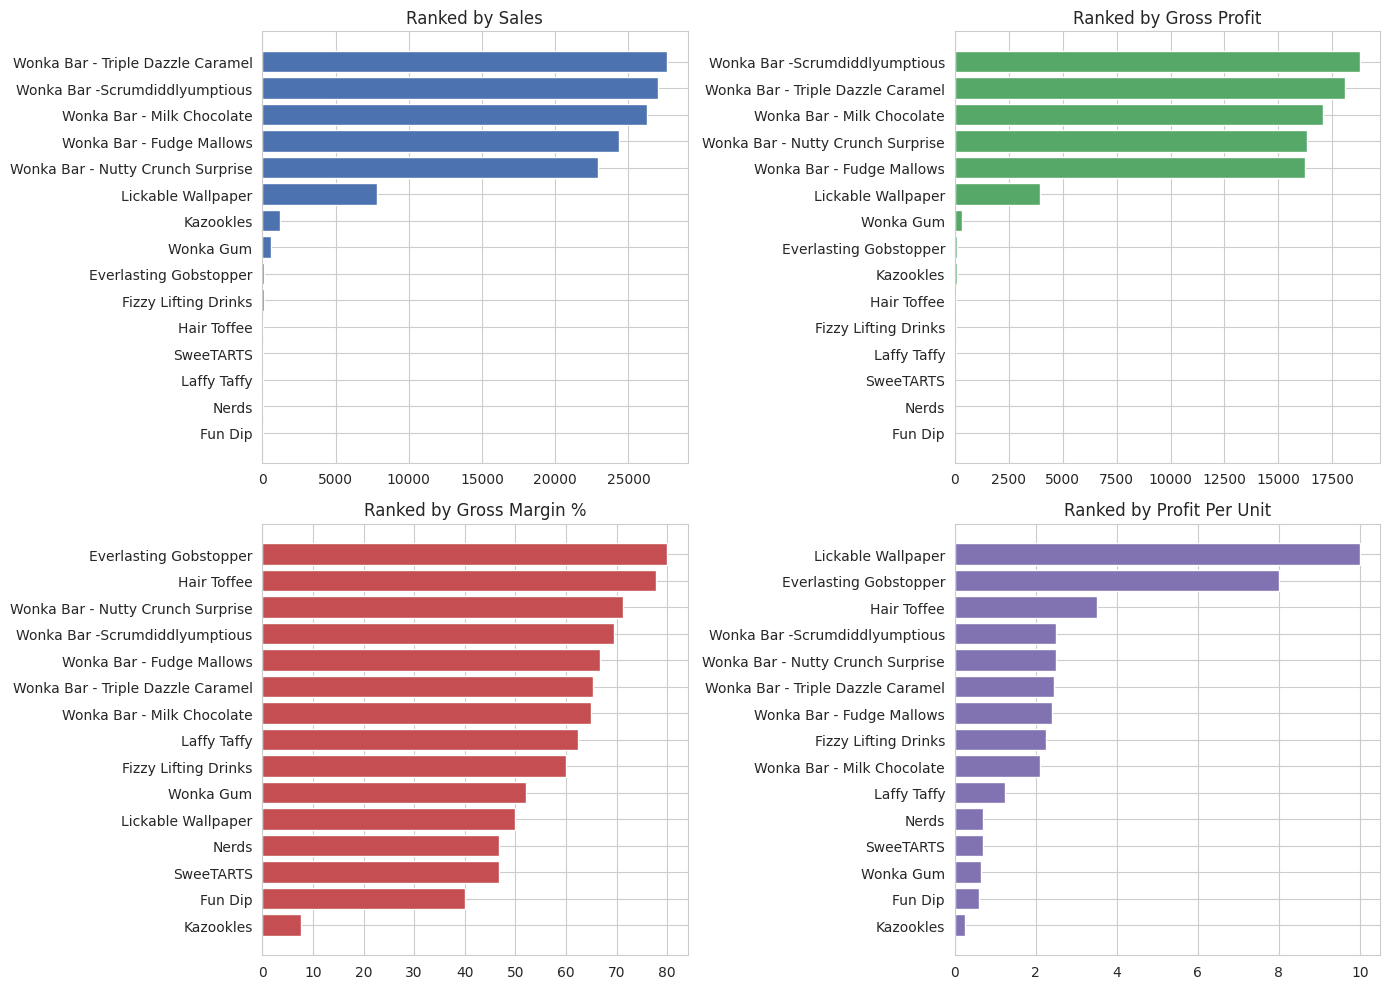

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

d = product_table.sort_values('Sales', ascending=True)
axes[0,0].barh(d['Product Name'], d['Sales'], color='#4C72B0'); axes[0,0].set_title('Ranked by Sales')

d = product_table.sort_values('Gross_Profit', ascending=True)
axes[0,1].barh(d['Product Name'], d['Gross_Profit'], color='#55A868'); axes[0,1].set_title('Ranked by Gross Profit')

d = product_table.sort_values('Gross_Margin_Pct', ascending=True)
axes[1,0].barh(d['Product Name'], d['Gross_Margin_Pct'], color='#C44E52'); axes[1,0].set_title('Ranked by Gross Margin %')

d = product_table.sort_values('Profit_Per_Unit', ascending=True)
axes[1,1].barh(d['Product Name'], d['Profit_Per_Unit'], color='#8172B2'); axes[1,1].set_title('Ranked by Profit Per Unit')

plt.tight_layout()
plt.savefig('../images/product_rankings.png', dpi=120)
plt.show()

## 6. Segmenting Products — Documented Thresholds

In [7]:
sales_median = product_table['Sales'].median()
margin_median = product_table['Gross_Margin_Pct'].median()

print(f"Sales median across products: ${sales_median:,.2f}")
print(f"Gross Margin median across products: {margin_median:.2f}%")

def segment(row):
    high_sales = row['Sales'] >= sales_median
    high_margin = row['Gross_Margin_Pct'] >= margin_median
    if high_sales and high_margin:
        return 'High Performing'
    elif high_sales and not high_margin:
        return 'Margin Risk'
    elif not high_sales and high_margin:
        return 'Potential Opportunity'
    else:
        return 'Requires Review'

product_table['Segment'] = product_table.apply(segment, axis=1)
product_table[['Product Name', 'Division', 'Sales', 'Gross_Margin_Pct', 'Segment']].sort_values('Segment')

Sales median across products: $597.50
Gross Margin median across products: 62.31%


,Product Name,Division,Sales,Gross_Margin_Pct,Segment
0,Wonka Bar - Triple Dazzle Caramel,Chocolate,27648.75,65.33,High Performing
1,Wonka Bar -Scrumdiddlyumptious,Chocolate,27028.80,69.44,High Performing
2,Wonka Bar - Milk Chocolate,Chocolate,26256.75,64.92,High Performing
3,Wonka Bar - Fudge Mallows,Chocolate,24361.20,66.67,High Performing
4,Wonka Bar - Nutty Crunch Surprise,Chocolate,22897.89,71.35,High Performing
5,Lickable Wallpaper,Other,7860.00,50.00,Margin Risk
6,Kazookles,Other,1205.75,7.69,Margin Risk
7,Wonka Gum,Other,597.50,52.00,Margin Risk
8,Everlasting Gobstopper,Sugar,130.00,80.00,Potential Opportunity
10,Hair Toffee,Sugar,76.50,77.78,Potential Opportunity


**Methodology note:** Products are split relative to the **median** Sales and median Gross Margin %
across all 15 products (a standard, non-arbitrary threshold for a small product catalog like this one).

- **High Performing** — Sales ≥ median AND Margin ≥ median
- **Margin Risk** — Sales ≥ median but Margin < median (sells well, but profitability is comparatively weak)
- **Potential Opportunity** — Sales < median but Margin ≥ median (profitable per dollar, but under-sold)
- **Requires Review** — Sales < median AND Margin < median

These are **review flags for further investigation**, not verdicts — see the caveat in the notebook summary.

In [8]:
product_table['Segment'].value_counts()

Segment
High Performing          5
Requires Review          4
Margin Risk              3
Potential Opportunity    3
Name: count, dtype: int64

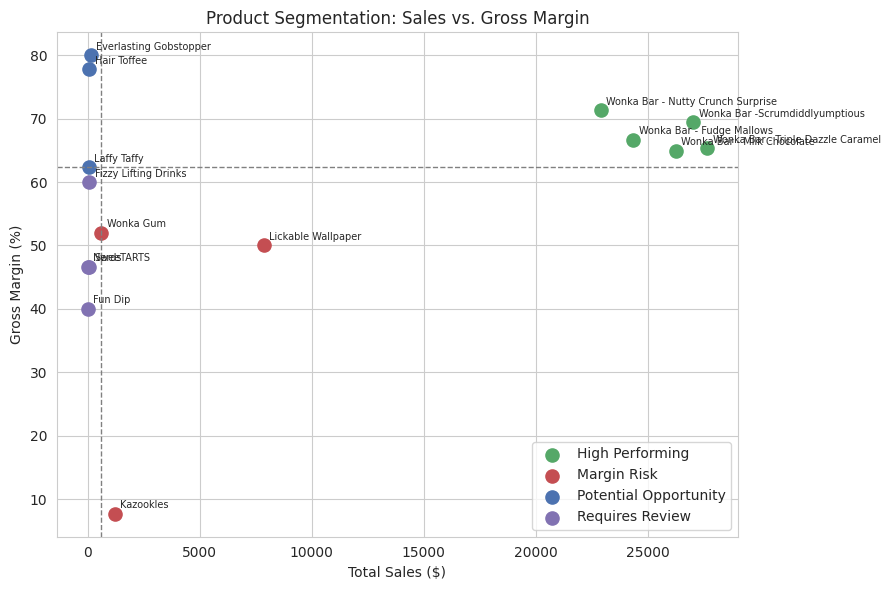

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = {'High Performing': '#55A868', 'Margin Risk': '#C44E52',
          'Potential Opportunity': '#4C72B0', 'Requires Review': '#8172B2'}
for seg, grp in product_table.groupby('Segment'):
    ax.scatter(grp['Sales'], grp['Gross_Margin_Pct'], label=seg, s=90, color=colors[seg])
for _, r in product_table.iterrows():
    ax.annotate(r['Product Name'], (r['Sales'], r['Gross_Margin_Pct']), fontsize=7,
                xytext=(4, 4), textcoords='offset points')
ax.axvline(sales_median, color='grey', linestyle='--', linewidth=1)
ax.axhline(margin_median, color='grey', linestyle='--', linewidth=1)
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Gross Margin (%)')
ax.set_title('Product Segmentation: Sales vs. Gross Margin')
ax.legend()
plt.tight_layout()
plt.savefig('../images/product_segmentation.png', dpi=120)
plt.show()

## 7. Notebook 2 Summary

In [10]:
print("Products flagged 'Margin Risk' (high sales, weak margin):")
print(product_table.loc[product_table['Segment']=='Margin Risk', 'Product Name'].tolist())
print()
print("Products flagged 'High Performing':")
print(product_table.loc[product_table['Segment']=='High Performing', 'Product Name'].tolist())
print()
print("Products flagged 'Potential Opportunity':")
print(product_table.loc[product_table['Segment']=='Potential Opportunity', 'Product Name'].tolist())
print()
print("Products flagged 'Requires Review':")
print(product_table.loc[product_table['Segment']=='Requires Review', 'Product Name'].tolist())

Products flagged 'Margin Risk' (high sales, weak margin):
['Lickable Wallpaper', 'Kazookles', 'Wonka Gum']

Products flagged 'High Performing':
['Wonka Bar - Triple Dazzle Caramel', 'Wonka Bar -Scrumdiddlyumptious', 'Wonka Bar - Milk Chocolate', 'Wonka Bar - Fudge Mallows', 'Wonka Bar - Nutty Crunch Surprise']

Products flagged 'Potential Opportunity':
['Everlasting Gobstopper', 'Hair Toffee', 'Laffy Taffy']

Products flagged 'Requires Review':
['Fizzy Lifting Drinks', 'SweeTARTS', 'Nerds', 'Fun Dip']


Product-level profitability metrics (margin, profit per unit, revenue/profit contribution, margin
volatility) were computed and saved to `data/product_profitability.csv`. Products were segmented against
median Sales/Margin thresholds into **High Performing**, **Margin Risk**, **Potential Opportunity**, and
**Requires Review** — these are directional review flags, not automatic business decisions, and are used as
input to the division and Pareto analysis in Notebook 3, and to the Streamlit dashboard.